In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [125]:
data = pd.read_csv('SuperMarket - SuperMarket.csv')

In [126]:
df = pd.DataFrame(data)

In [127]:
df.shape
df.columns
df.dtypes
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1014 non-null   object 
 1   Branch                   1014 non-null   object 
 2   City                     1014 non-null   object 
 3   Customer type            1014 non-null   object 
 4   Gender                   1014 non-null   object 
 5   Product line             1014 non-null   object 
 6   Unit price               990 non-null    float64
 7   Quantity                 1014 non-null   int64  
 8   Tax 5%                   1014 non-null   float64
 9   Sales                    994 non-null    object 
 10  Date                     1002 non-null   object 
 11  Time                     1014 non-null   object 
 12  Payment                  1014 non-null   object 
 13  cogs                     1014 non-null   float64
 14  gross margin percentage 

Invoice ID                  0
Branch                      0
City                        0
Customer type               0
Gender                      0
Product line                0
Unit price                 24
Quantity                    0
Tax 5%                      0
Sales                      20
Date                       12
Time                        0
Payment                     0
cogs                        0
gross margin percentage     0
gross income                0
Rating                      0
dtype: int64

In [112]:
df.duplicated().sum()

np.int64(14)

In [113]:
df.describe()
df.nunique()

Invoice ID                 1000
Branch                        5
City                          3
Customer type                 2
Gender                        4
Product line                  6
Unit price                  921
Quantity                     10
Tax 5%                      990
Sales                       970
Date                         89
Time                        506
Payment                       6
cogs                        990
gross margin percentage       1
gross income                990
Rating                       61
dtype: int64

#### The unit price contains 24 missing values.
#### The gross margin percentage column contains one unique value which is 4.761904762. Since there's no variation between the rows it is condiered suspicious and needs to be dropped. 
#### Tax 5% and gross income columns are exactly the same so i can drop one of the columns and keep the other.

In [114]:
df.columns
df.dtypes

Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Sales                       object
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

In [115]:
df['Sales'] = df['Sales'].str.replace('EGP', '', regex=False).astype(float)
df.loc[df['Unit price'].isnull(), 'Unit price'] = (df['Sales'] / (df['Quantity'] * 1.05))
df['Unit price'].isna().sum()

np.int64(0)

In [116]:
df['Sales'] = df['Quantity'] * df['Unit price'] * 1.05
df['Sales'].isna().sum()

np.int64(0)

In [129]:
df.drop_duplicates()
df.drop('gross income', axis=1)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.22,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.048,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,NaN,10:37:00 AM,E-wallet,604.17,4.761905,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1009,886-18-2897,Alex,Yangon,Normal,Female,Food and beverages,56.56,5,14.1400,296.94,3/22/2019,7:06:00 PM,Credit card,282.80,4.761905,4.5
1010,602-16-6955,Cairo,Mandalay,Normal,Female,Sports and travel,76.60,10,38.3000,804.3,1/24/2019,6:10:00 PM,Ewallet,766.00,4.761905,6.0
1011,745-74-0715,Alex,Yangon,Normal,Male,Electronic accessories,58.03,2,5.8030,121.863,3/10/2019,8:46:00 PM,Ewallet,116.06,4.761905,8.8
1012,690-01-6631,Cairo,Mandalay,Normal,Male,Fashion accessories,17.49,10,8.7450,183.645,2/22/2019,6:35:00 PM,Ewallet,174.90,4.761905,6.6


In [118]:
df['Date'] = pd.to_datetime(df['Date'])
df['Day'] = df['Date'].dt.day.astype('Int64')
df['Month'] = df['Date'].dt.month.astype('Int64')
df['Year'] = df['Date'].dt.year.astype('Int64')

In [119]:
df[['Date', 'Day', 'Month', 'Year']].head()

,Date,Day,Month,Year
0,2019-01-05,5,1,2019
1,2019-03-08,8,3,2019
2,2019-03-03,3,3,2019
3,2019-01-27,27,1,2019
4,NaT,<NA>,<NA>,<NA>


In [120]:
df['Satisfied'] = df['Rating'].apply(lambda x: "Satisfied" if x >= 7 else "Not Satisfied")
df.head

<bound method NDFrame.head of        Invoice ID Branch       City Customer type  Gender  \
0     750-67-8428   Alex     Yangon        Member  Female   
1     226-31-3081   Giza  Naypyitaw        Normal  Female   
2     631-41-3108   Alex     Yangon        Normal  Female   
3     123-19-1176   Alex     Yangon        Member  Female   
4     373-73-7910   Alex     Yangon        Member  Female   
...           ...    ...        ...           ...     ...   
1009  886-18-2897   Alex     Yangon        Normal  Female   
1010  602-16-6955  Cairo   Mandalay        Normal  Female   
1011  745-74-0715   Alex     Yangon        Normal    Male   
1012  690-01-6631  Cairo   Mandalay        Normal    Male   
1013  652-49-6720   Giza  Naypyitaw        Member  Female   

                Product line  Unit price  Quantity   Tax 5%     Sales  \
0          Health and beauty       74.69         7  26.1415  548.9715   
1     Electronic accessories       15.28         5   3.8200   80.2200   
2         Home and

## Data Analysis

### Total Revenue

In [104]:
total_revenue = df['Sales'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 326583.348


### Revenue By City

Naypyitaw
111215.853


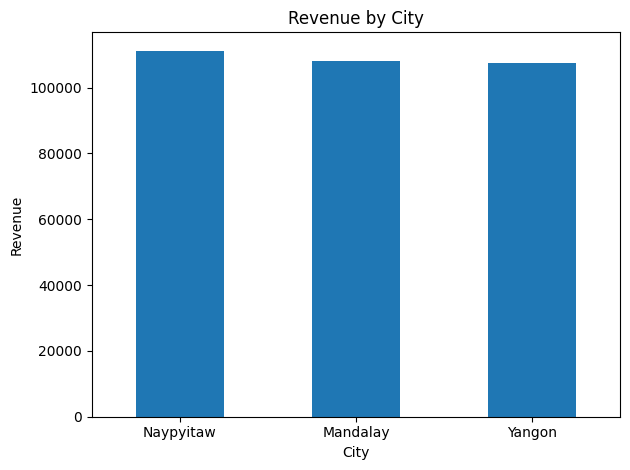

In [87]:
revenue_by_city = df.groupby('City')['Sales'].sum().sort_values(ascending=False)

highest_revenue_city = revenue_by_city.idxmax()
highest_revenue = revenue_by_city.max()

print(highest_revenue_city)
print(highest_revenue)
revenue_by_city.plot(kind='bar')

plt.title('Revenue by City')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Profit By Branch

Profit by Branch:
Branch
Giza     5284.5930
Alex     5114.8495
Cairo    5105.8755
cairo      34.8700
giza       11.4000
Name: Profit, dtype: float64

Most Profitable Branch: Giza
Total Profit: 5284.59


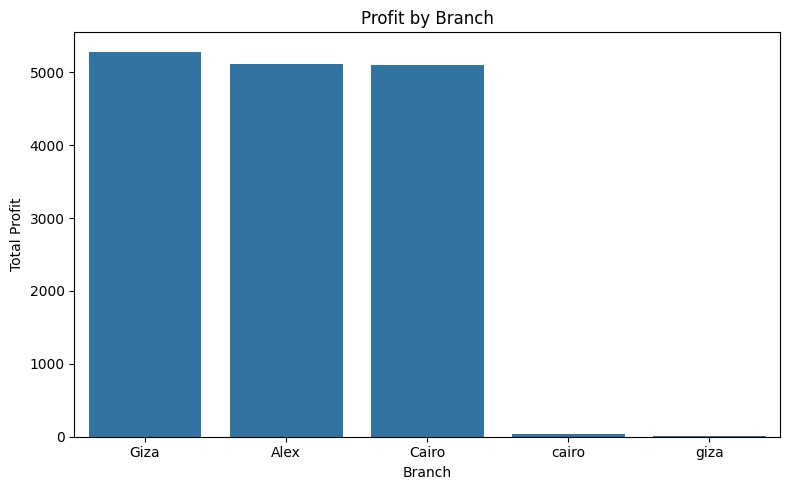

In [105]:
df['Profit'] = df['Sales'] - df['cogs']
profit_by_branch = df.groupby('Branch')['Profit'].sum().sort_values(ascending=False)
print("Profit by Branch:")
print(profit_by_branch)

most_profitable_branch = profit_by_branch.idxmax()
highest_profit = profit_by_branch.max()

print("\nMost Profitable Branch:", most_profitable_branch)
print(f"Total Profit: {highest_profit:.2f}")

plt.figure(figsize=(8, 5))

sns.barplot(
    x=profit_by_branch.index,
    y=profit_by_branch.values
)

plt.title('Profit by Branch')
plt.xlabel('Branch')
plt.ylabel('Total Profit')
plt.tight_layout()
plt.show()

### Revenue And Profit By Product Category


Highest Revenue Category: Food and beverages
Highest Revenue: 56819.805

Highest Profit Category: Food and beverages
Highest Profit: 2705.705000000002


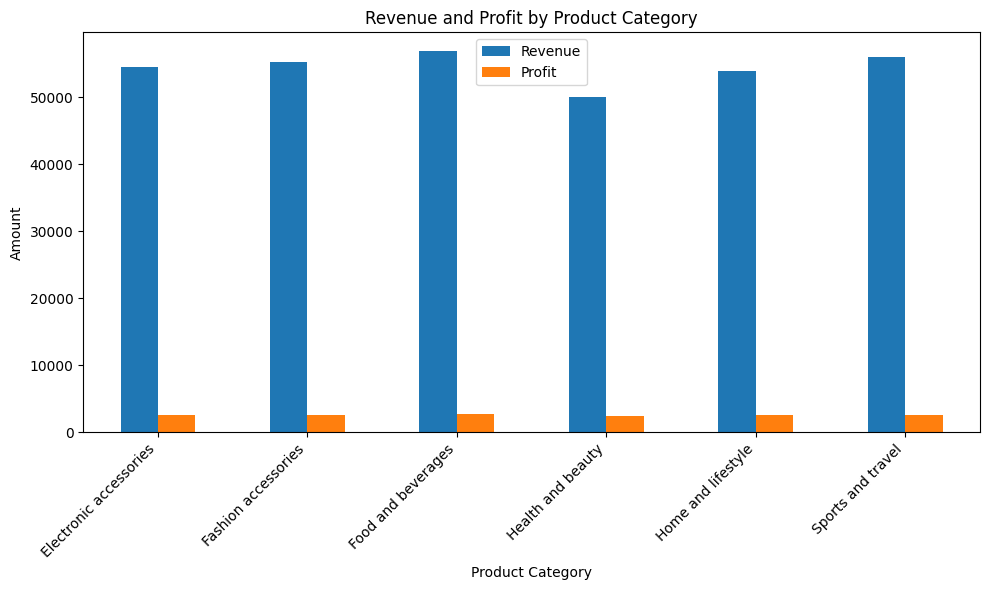

In [106]:
revenue_profit_category = df.groupby('Product line')[['Sales', 'Profit']].sum()
top_revenue_category = revenue_profit_category['Sales'].idxmax()
top_revenue = revenue_profit_category['Sales'].max()
top_profit_category = revenue_profit_category['Profit'].idxmax()
top_profit = revenue_profit_category['Profit'].max()

print("\nHighest Revenue Category:", top_revenue_category)
print("Highest Revenue:", top_revenue)

print("\nHighest Profit Category:", top_profit_category)
print("Highest Profit:", top_profit)

revenue_profit_category.plot(kind='bar', figsize=(10, 6))

plt.title('Revenue and Profit by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Amount')
plt.xticks(rotation=45, ha='right')
plt.legend(['Revenue', 'Profit'])
plt.tight_layout()

plt.show()

### Spending By Customer Type


Customer Type That Spends More: Member
Total Spending: 191025.77550000002


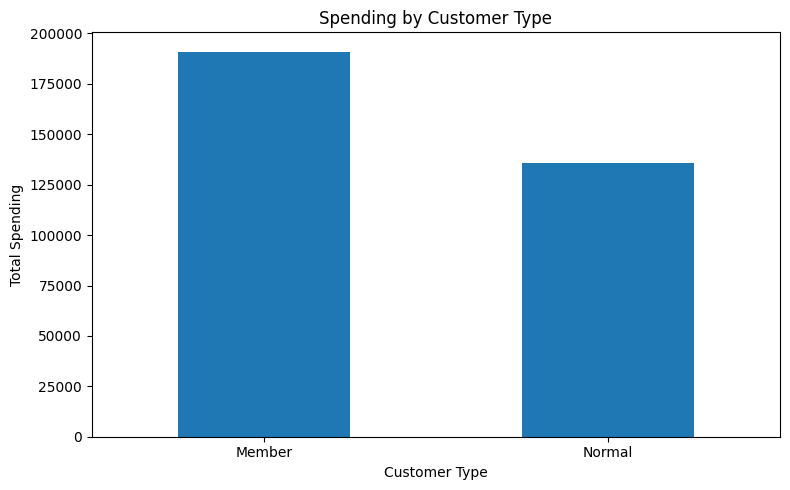

In [107]:
spending_by_customer = df.groupby('Customer type')['Sales'].sum()
top_customer_type = spending_by_customer.idxmax()
top_spending = spending_by_customer.max()

print("\nCustomer Type That Spends More:", top_customer_type)
print("Total Spending:", top_spending)

spending_by_customer.plot(kind='bar', figsize=(8, 5))

plt.title('Spending by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Total Spending')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

### Payment Method

Payment Method Counts:
Payment
Ewallet        355
Cash           338
Credit card    309
cash             7
credit card      5
Name: count, dtype: int64

Most Popular Payment Method: Ewallet
Number of Transactions: 355


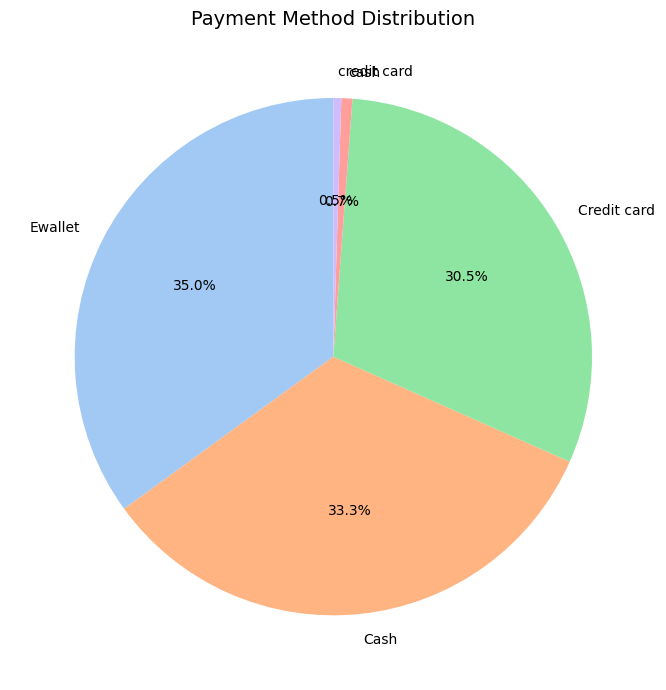

In [94]:
df['Payment'] = df['Payment'].replace('E-wallet', 'Ewallet')
payment_counts = df['Payment'].value_counts()

print("Payment Method Counts:")
print(payment_counts)
most_popular_payment = payment_counts.idxmax()
most_popular_count = payment_counts.max()

print("\nMost Popular Payment Method:", most_popular_payment)
print("Number of Transactions:", most_popular_count)

colors = sns.color_palette('pastel', len(payment_counts))

plt.figure(figsize=(7, 7))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

plt.title('Payment Method Distribution', fontsize=14)
plt.tight_layout()
plt.show()

### Average Transaction Value

Average Transaction Value: 322.07


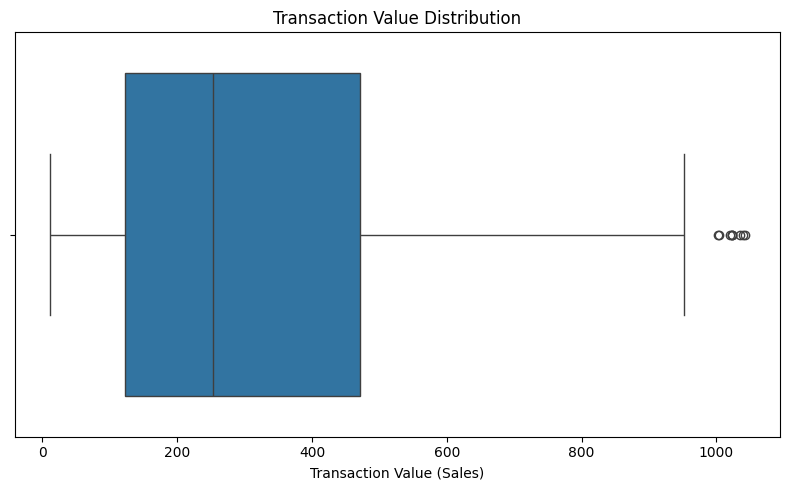

In [98]:
average_transaction_value = df['Sales'].mean()
print(f"Average Transaction Value: {average_transaction_value:.2f}")

plt.figure(figsize=(8, 5))

sns.boxplot(x=df['Sales'])

plt.title('Transaction Value Distribution')
plt.xlabel('Transaction Value (Sales)')

plt.tight_layout()
plt.show()

### Customer Satisfaction By Branch

Average Customer Satisfaction by Branch:
Branch
cairo    8.900000
Giza     7.069394
Alex     7.018895
Cairo    6.789941
giza     6.600000
Name: Rating, dtype: float64

Branch with the Highest Satisfaction: cairo
Average Rating: 8.90


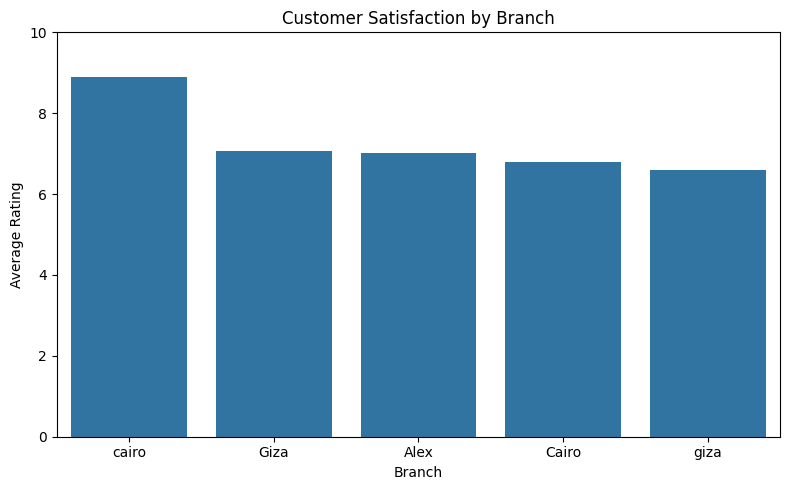

In [99]:
satisfaction_by_branch = df.groupby('Branch')['Rating'].mean().sort_values(ascending=False)

print("Average Customer Satisfaction by Branch:")
print(satisfaction_by_branch)
highest_satisfaction_branch = satisfaction_by_branch.idxmax()
highest_satisfaction_rating = satisfaction_by_branch.max()

print("\nBranch with the Highest Satisfaction:", highest_satisfaction_branch)
print(f"Average Rating: {highest_satisfaction_rating:.2f}")

plt.figure(figsize=(8, 5))

sns.barplot(
    x=satisfaction_by_branch.index,
    y=satisfaction_by_branch.values
)

plt.title('Customer Satisfaction by Branch')
plt.xlabel('Branch')
plt.ylabel('Average Rating')
plt.ylim(0, 10)
plt.tight_layout()
plt.show()

### Sales By Day And Month


Highest Sales Day: 15
Sales on Highest Sales Day: 15409.60

Highest Sales Month: 1
Sales in Highest Sales Month: 117103.31


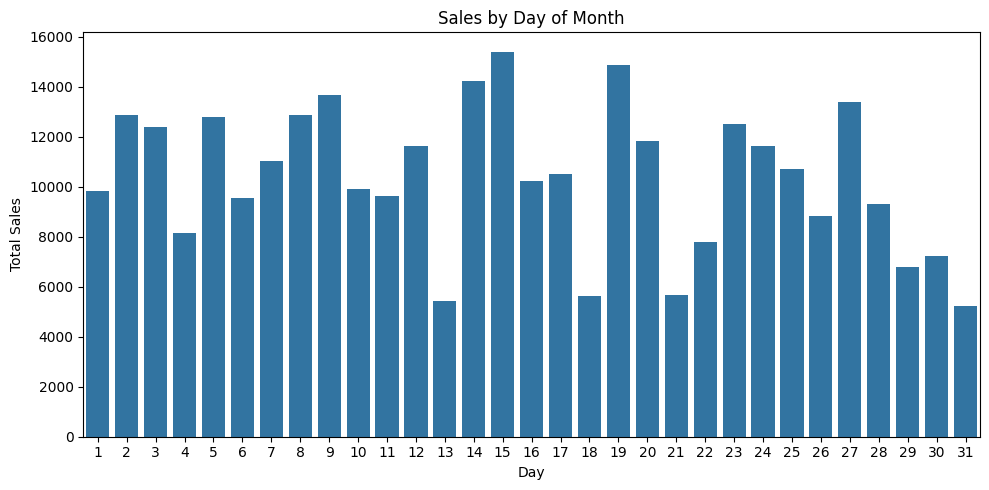

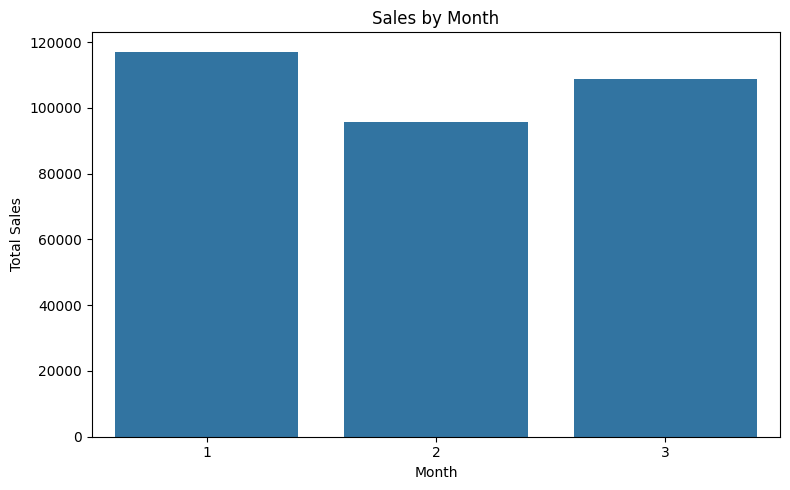

In [100]:
date_sales = df.dropna(subset=['Date']).copy()
sales_by_day = date_sales.groupby('Day')['Sales'].sum().sort_values(ascending=False)
sales_by_month = date_sales.groupby('Month')['Sales'].sum().sort_values(ascending=False)

highest_sales_day = sales_by_day.idxmax()
highest_sales_day_value = sales_by_day.max()

highest_sales_month = sales_by_month.idxmax()
highest_sales_month_value = sales_by_month.max()

print("\nHighest Sales Day:", highest_sales_day)
print(f"Sales on Highest Sales Day: {highest_sales_day_value:.2f}")

print("\nHighest Sales Month:", highest_sales_month)
print(f"Sales in Highest Sales Month: {highest_sales_month_value:.2f}")

plt.figure(figsize=(10, 5))

sns.barplot(
    x=sales_by_day.index,
    y=sales_by_day.values
)

plt.title('Sales by Day of Month')
plt.xlabel('Day')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=sales_by_month.index,
    y=sales_by_month.values
)

plt.title('Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

### Overall Customer Satisfaction

Overall Customer Satisfaction: 49.80%


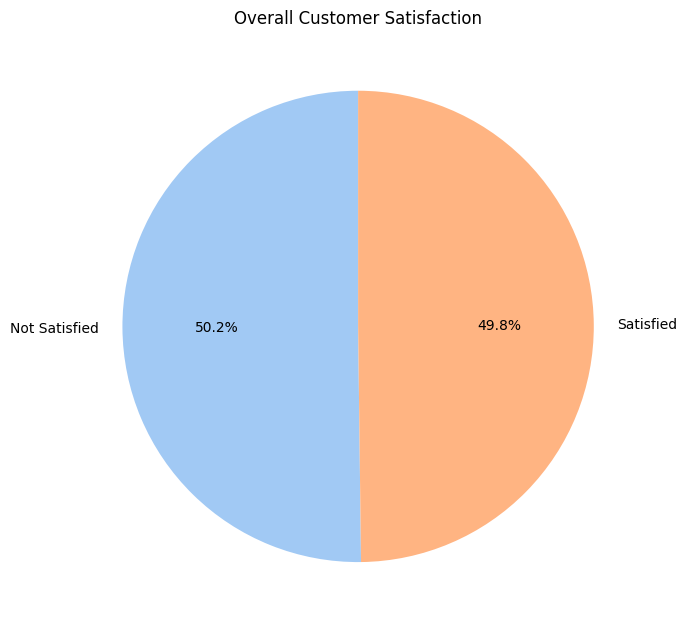

In [103]:
satisfaction_counts = df['Satisfied'].value_counts()
satisfied_percentage = (satisfaction_counts['Satisfied'] / satisfaction_counts.sum()) * 100
print(f"Overall Customer Satisfaction: {satisfied_percentage:.2f}%")

plt.figure(figsize=(7, 7))
colors = sns.color_palette('pastel', len(satisfaction_counts))

plt.pie(
    satisfaction_counts,
    labels=satisfaction_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

plt.title('Overall Customer Satisfaction')
plt.tight_layout()
plt.show()